# SNI with an overlapping decomposition — DeepONet local operator

Schwarz Neural Inference (arXiv:2504.00510, Algorithm 1) on the jagged-channel
Navier–Stokes data, using the trained DeepONet as the frozen local operator.

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path
from weakref import WeakKeyDictionary

import numpy as np
import torch
import matplotlib.pyplot as plt

MODULE_DIR = Path.cwd()
if not (MODULE_DIR / "fluent_deeponet.py").exists():
    MODULE_DIR = MODULE_DIR / "DeepONet"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

# The overlapping decomposition lives in the SNI repo.
SNI_REPO = Path("/home/hantianl/Documents/sni")
if str(SNI_REPO) not in sys.path:
    sys.path.insert(0, str(SNI_REPO))

from fluent_deeponet import DeepONet, FeatureNormalizer
from deeponet_fluent_dataset import normalize_cell_branch_with_y
from utils.channel_overlap import build_overlapping_decomposition, VALUE_COLS

print("DeepONet module:", MODULE_DIR)
print("SNI repo       :", SNI_REPO)

DeepONet module: /home/hantianl/Documents/PIDIF/DeepONet
SNI repo       : /home/hantianl/Documents/sni


## Configuration

In [ ]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
CKPT_PATH = MODULE_DIR / "results" / "061626_2" / "checkpoint.pt"

ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/")
DATASET_NAME = "channel_water"

OVERLAP_FRAC = 0.25
N_SUBDOMAINS = 10

UPDATE = "additive"
TAU = 0.4
MAX_ITER = 300
RTOL = 1e-6
INIT = "normalized_zero"
QUERY_CHUNK = 200000


def case_paths(ch):
    return {
        "design": ROOT_DIR / f"2d_geometry_specs/{DATASET_NAME}/{ch}.json",
        "mesh": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/{ch}.msh.h5",
        "dat": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/case2d.dat.h5",
    }

## Load the trained DeepONet

In [3]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

model = DeepONet(**ckpt["model_config"]).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(DEVICE)
LOCAL_ASPECT_MEAN = float(ckpt["local_aspect_mean"])
LOCAL_ASPECT_STD = float(ckpt["local_aspect_std"])
BRANCH_CHANNELS = list(ckpt["branch_channel_names"])
FIELD_NAMES = list(ckpt["output_channel_names"])
TEST_CASES = list(ckpt["test_cases"])

# The decomposition must use the sensor counts the operator was trained with.
N_INTERFACE_POINTS = int(ckpt["n_interface_points"])
N_WALL_POINTS = int(ckpt["n_wall_points"])
BC_KWARGS = dict(ckpt["bc_kwargs"])
FIELD_MAP = dict(ckpt["field_map"])

y_mean = y_normalizer.mean.detach().cpu().numpy().reshape(-1)[:3]
y_std = y_normalizer.std.detach().cpu().numpy().reshape(-1)[:3]

print(f"checkpoint      : {CKPT_PATH}")
print(f"fields          : {FIELD_NAMES}")
print(f"branch channels : {len(BRANCH_CHANNELS)}  interface/wall pts: {N_INTERFACE_POINTS}/{N_WALL_POINTS}")
print(f"trained on      : {ckpt['n_subdomains']} subdomains, placement={ckpt['interface_placement']}")
print(f"local_aspect    : mean={LOCAL_ASPECT_MEAN:.4f} std={LOCAL_ASPECT_STD:.4f}")
print(f"y mean/std      : {np.round(y_mean, 5)} / {np.round(y_std, 5)}")
print(f"test cases ({len(TEST_CASES)}): {TEST_CASES}")

checkpoint      : /home/hantianl/Documents/PIDIF/DeepONet/results/061626_2/checkpoint.pt
fields          : ['pressure', 'u', 'v']
branch channels : 11  interface/wall pts: 256/256
trained on      : 10 subdomains, placement=random
local_aspect    : mean=1.0000 std=0.8170
y mean/std      : [ 6.438737e+02  1.001160e+00 -1.000000e-05] / [4.124969e+02 4.277600e-01 2.241000e-02]
test cases (20): ['channel_18', 'channel_22', 'channel_28', 'channel_31', 'channel_33', 'channel_45', 'channel_51', 'channel_71', 'channel_81', 'channel_89', 'channel_90', 'channel_97', 'channel_111', 'channel_117', 'channel_118', 'channel_133', 'channel_151', 'channel_172', 'channel_193', 'channel_199']


## Local operator wrapper

DeepONet's trunk is pointwise, so its ragged mode (`query_batch_id`) evaluates every
subdomain in a single padding-free forward — all `K` branches at once, each query point
routed to its own branch coefficients.

In [4]:
class DeepONetLocalOperator:
    '''Frozen DeepONet evaluated on a whole decomposition at once.

    Takes physical-unit branches, applies exactly the training-time preprocessing
    (`normalize_cell_branch_with_y`), and returns physical-unit predictions.
    '''

    def __init__(self, model, y_normalizer, branch_channels, device,
                 local_aspect_mean, local_aspect_std, query_chunk=200_000):
        self.model = model
        self.y_normalizer = y_normalizer
        self.branch_channels = list(branch_channels)
        self.device = device
        self.local_aspect_mean = local_aspect_mean
        self.local_aspect_std = local_aspect_std
        self.query_chunk = int(query_chunk)
        # Keyed by the decomposition object, not id(): the ablation and sweep loops
        # rebuild `dec` each iteration and a freed object's id can be reused, which
        # would silently hand back another case's query points.
        self._query_cache = WeakKeyDictionary()

    def _queries(self, dec):
        if dec not in self._query_cache:
            q = np.concatenate([s.query for s in dec.subdomains], axis=0)
            bid = np.concatenate([np.full(s.query.shape[0], k, dtype=np.int64)
                                  for k, s in enumerate(dec.subdomains)])
            self._query_cache[dec] = (
                torch.from_numpy(q.astype(np.float32)).to(self.device),
                torch.from_numpy(bid).to(self.device),
            )
        return self._query_cache[dec]

    @torch.no_grad()
    def __call__(self, dec, branches):
        '''branches: list of (M, C) physical-unit arrays -> list of (Q_k, 3) physical.'''
        norm = np.stack([
            normalize_cell_branch_with_y(
                b,
                branch_channel_names=self.branch_channels,
                target_y_normalizer=self.y_normalizer,
                local_aspect_mean=self.local_aspect_mean,
                local_aspect_std=self.local_aspect_std,
            )
            for b in branches
        ], axis=0)
        branch_t = torch.from_numpy(norm).to(self.device)          # (K, M, C)

        query, batch_id = self._queries(dec)
        outs = []
        for start in range(0, query.shape[0], self.query_chunk):
            stop = start + self.query_chunk
            out = self.model(branch_t, query[start:stop], query_batch_id=batch_id[start:stop])
            outs.append(self.y_normalizer.decode(out).cpu())
        pred = torch.cat(outs, dim=0).numpy().astype(np.float64)

        sizes = [s.query.shape[0] for s in dec.subdomains]
        if sum(sizes) != pred.shape[0]:
            raise RuntimeError(f"query cache mismatch: {sum(sizes)} vs {pred.shape[0]}")
        bounds = np.cumsum([0] + sizes)
        return [pred[bounds[i]:bounds[i + 1]] for i in range(len(sizes))]


operator = DeepONetLocalOperator(
    model, y_normalizer, BRANCH_CHANNELS, DEVICE,
    LOCAL_ASPECT_MEAN, LOCAL_ASPECT_STD, query_chunk=QUERY_CHUNK,
)
print("local operator ready")

local operator ready


## Schwarz driver

`u` is the global field on every Fluent cell centre. One sweep:

1. sample `u` at each subdomain's artificial boundary and write it into that
   subdomain's branch (global inlet/outlet/wall rows keep their prescribed values),
2. project each interface trace onto the incompressibility constraint,
3. run the frozen operator on every subdomain,
4. stitch with the relaxed additive-Schwarz update.

In [ ]:
from utils.channel_overlap import BarycentricInterpolator

LO, HI = VALUE_COLS[0], VALUE_COLS[-1] + 1
U_IDX, V_IDX = VALUE_COLS[1] - LO, VALUE_COLS[2] - LO

class OverlapSNI:
    def __init__(self, operator, y_mean, update="averaged"):
        self.op = operator
        self.y_mean = np.asarray(y_mean, dtype=np.float64).reshape(-1)[:3]
        if update not in ("averaged", "additive"):
            raise ValueError("update must be 'averaged' or 'additive'")
        self.update = update
        self._prep = WeakKeyDictionary()

    def prepare(self, dec):
        if dec not in self._prep:
            targets, slots, cursor = [], [], 0
            for sub in dec.subdomains:
                for side, xy, is_global in (("left", sub.left_xy, sub.left_is_global),
                                            ("right", sub.right_xy, sub.right_is_global)):
                    if is_global:
                        continue          # inlet/outlet keep their prescribed BC
                    targets.append(xy)
                    slots.append((sub.subdomain_id, side, slice(cursor, cursor + xy.shape[0])))
                    cursor += xy.shape[0]
            interp = BarycentricInterpolator(dec.points, np.concatenate(targets, 0)) if targets else None
            self._prep[dec] = (interp, slots)
        return self._prep[dec]

    def initialize(self, dec, mode="normalized_zero"):
        n = dec.points.shape[0]
        mode = {"mean": "normalized_zero", "zeros": "physical_zero"}.get(mode, mode)
        if mode == "physical_zero":
            return np.zeros((n, 3), dtype=np.float64)
        if mode != "normalized_zero":
            raise ValueError(f"unknown init mode {mode!r}")
        return np.tile(self.y_mean, (n, 1))

    def local_inputs(self, dec, u):
        interp, slots = self.prepare(dec)
        branches = [s.branch0.copy() for s in dec.subdomains]
        if interp is None:
            return branches
        sampled = interp(u)
        for sub_id, side, sl in slots:
            sub = dec.subdomains[sub_id]
            rows = sub.left_rows if side == "left" else sub.right_rows
            trace = sampled[sl].copy()
            branches[sub_id][rows, LO:HI] = trace
        return branches

    def stitch(self, dec, preds):
        acc = np.zeros_like(dec.truth, dtype=np.float64)
        for sub, pred in zip(dec.subdomains, preds):
            acc[sub.cell_idx] += pred
        return acc

    def step(self, dec, u, preds, tau):
        stitched = self.stitch(dec, preds)
        if self.update == "additive":          # paper Eq. 2 / Algorithm 1 line 7
            return u + tau * (stitched - dec.coverage * u)
        return (1.0 - tau) * u + tau * (stitched / dec.coverage)

    @staticmethod
    def rel_l2(pred, truth):
        num = np.sqrt(((pred - truth) ** 2).sum(axis=0))
        den = np.sqrt((truth ** 2).sum(axis=0)) + 1e-12
        return num / den

    def teacher_forced(self, dec):
        '''Operator error with ground-truth interface values: the accuracy ceiling.'''
        preds = self.op(dec, [s.branch0 for s in dec.subdomains])
        return self.rel_l2(self.stitch(dec, preds) / dec.coverage, dec.truth)

    def solve(self, dec, tau=TAU, max_iter=MAX_ITER, rtol=RTOL,
              init=INIT, verbose=False):
        u = self.initialize(dec, init)
        metric_hist, update_hist, stop = [], [], "max_iter"
        for it in range(max_iter):
            preds = self.op(dec, self.local_inputs(dec, u))
            u_next = self.step(dec, u, preds, tau)
            if not np.all(np.isfinite(u_next)):
                stop = "nonfinite"; break
            upd = float(np.linalg.norm(u_next - u) / max(np.linalg.norm(u), 1e-12))
            u = u_next
            update_hist.append(upd)
            metric_hist.append(self.rel_l2(u, dec.truth))
            if verbose and (it % 25 == 0 or it == max_iter - 1):
                m = metric_hist[-1]
                print(f"  it{it:4d} upd={upd:.3e} rel-L2 " +
                      " ".join(f"{n}={v:.4e}" for n, v in zip(FIELD_NAMES, m)))
            if upd < rtol:
                stop = "converged"; break
        return {"solution": u, "steps": len(update_hist), "stop_reason": stop,
                "metric_history": metric_hist, "update_history": update_hist,
                "final_metric": metric_hist[-1] if metric_hist else np.full(3, np.nan)}


driver = OverlapSNI(operator, y_mean, update=UPDATE)
print("driver ready")

driver ready


## Single case

In [7]:
def build(case_id, n_subdomains=N_SUBDOMAINS, overlap_frac=OVERLAP_FRAC):
    p = case_paths(case_id)
    return build_overlapping_decomposition(
        case_id, Path(p["dat"]), Path(p["mesh"]), Path(p["design"]),
        n_subdomains=n_subdomains,
        n_interface_points=N_INTERFACE_POINTS,
        n_boundary_points=N_WALL_POINTS,
        overlap_frac=overlap_frac,
        output_fields=FIELD_NAMES,
        bc_kwargs=BC_KWARGS,
        field_map=FIELD_MAP,
        pidif_deeponet_dir=MODULE_DIR,
    )


CASE = TEST_CASES[0]
dec = build(CASE)
aspect = dec.subdomains[1].branch0[0, BRANCH_CHANNELS.index("local_aspect_ratio")]
print(f"{CASE}: {dec.n_subdomains} subdomains, overlap factor t={dec.overlap_factor}, "
      f"{dec.points.shape[0]:,} cells")
print(f"local_aspect_ratio={aspect:.3f}  (training mean={LOCAL_ASPECT_MEAN:.3f} "
      f"std={LOCAL_ASPECT_STD:.3f} -> {(aspect-LOCAL_ASPECT_MEAN)/LOCAL_ASPECT_STD:+.2f} sigma)")

t0 = time.perf_counter()
ceiling = driver.teacher_forced(dec)
result = driver.solve(dec, verbose=True)
print(f"\nsteps={result['steps']} stop={result['stop_reason']} "
      f"time={time.perf_counter()-t0:.1f}s")
print("SNI      rel-L2:", " ".join(f"{n}={v:.4e}" for n, v in zip(FIELD_NAMES, result["final_metric"])))
print("ceiling  rel-L2:", " ".join(f"{n}={v:.4e}" for n, v in zip(FIELD_NAMES, ceiling)))
print("SNI / ceiling  :", np.round(result["final_metric"] / ceiling, 2))

channel_18: 10 subdomains, overlap factor t=2, 240,746 cells
local_aspect_ratio=1.500  (training mean=1.000 std=0.817 -> +0.61 sigma)
  it   0 upd=9.879e-02 rel-L2 pressure=4.8385e-01 u=2.9955e-01 v=1.2294e+00
  it  25 upd=7.833e-03 rel-L2 pressure=2.3861e-01 u=8.7566e-03 v=3.8554e-01
  it  50 upd=2.075e-03 rel-L2 pressure=1.9299e-01 u=8.2978e-03 v=4.0969e-01
  it  75 upd=8.225e-04 rel-L2 pressure=1.5664e-01 u=8.4949e-03 v=4.2268e-01
  it 100 upd=2.601e-04 rel-L2 pressure=1.4516e-01 u=8.4744e-03 v=4.2275e-01
  it 125 upd=1.003e-04 rel-L2 pressure=1.4115e-01 u=8.4519e-03 v=4.2219e-01
  it 150 upd=4.529e-05 rel-L2 pressure=1.3943e-01 u=8.4417e-03 v=4.2193e-01
  it 175 upd=2.123e-05 rel-L2 pressure=1.3864e-01 u=8.4371e-03 v=4.2182e-01
  it 200 upd=9.967e-06 rel-L2 pressure=1.3826e-01 u=8.4350e-03 v=4.2177e-01
  it 225 upd=4.667e-06 rel-L2 pressure=1.3809e-01 u=8.4340e-03 v=4.2175e-01
  it 250 upd=2.207e-06 rel-L2 pressure=1.3801e-01 u=8.4335e-03 v=4.2174e-01
  it 275 upd=1.036e-06 rel-L2 

In [ ]:
hist = np.array(result["metric_history"])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for j, name in enumerate(FIELD_NAMES):
    ax[0].semilogy(hist[:, j], label=name)
    ax[0].axhline(ceiling[j], ls="--", lw=0.8, color=f"C{j}", alpha=0.6)
ax[0].set_xlabel("Schwarz iteration"); ax[0].set_ylabel("global rel-L2")
ax[0].set_title("error vs iteration (dashed = teacher-forced ceiling)")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].semilogy(result["update_history"], color="k")
ax[1].axhline(RTOL, ls="--", lw=0.8, color="r")
ax[1].set_xlabel("Schwarz iteration"); ax[1].set_ylabel(r"$\|u_{n+1}-u_n\| / \|u_n\|$")
ax[1].set_title("iterate change (the actual stopping signal)")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Ablation

The first row is the baseline actually reported. Rows below vary one
thing at a time; the last is our non-paper addition, kept separate.

In [ ]:
rows = []
for label, kw in [
    ("BASELINE (paper: overlap, 0-init, Eq.2)", dict()),
    ("  no overlap (overlap_frac=0)",          dict(overlap_frac=0.0)),
    ("  averaged update instead of Eq.2",      dict(update="averaged", tau=0.5)),
    ("  init = physical zero (not norm. zero)", dict(init="physical_zero")),
]:
    d = build(CASE, overlap_frac=kw.pop("overlap_frac", OVERLAP_FRAC))
    drv = OverlapSNI(operator, y_mean,
                     update=kw.pop("update", UPDATE))
    r = drv.solve(d, tau=kw.pop("tau", TAU), init=kw.pop("init", INIT))
    rows.append((label, r["final_metric"], r["steps"], r["stop_reason"]))
    print(f"{label:<40} steps={r['steps']:>4} {r['stop_reason']:<10} "
          f"mean={r['final_metric'].mean():.4e}")

print()
hdr = f"{'configuration':<40}" + "".join(f"{n:>12}" for n in FIELD_NAMES) + f"{'mean':>12}"
print(hdr); print("-" * len(hdr))
for label, m, _, _ in rows:
    print(f"{label:<40}" + "".join(f"{v:>12.4e}" for v in m) + f"{m.mean():>12.4e}")
print(f"{'teacher-forced ceiling':<40}" + "".join(f"{v:>12.4e}" for v in ceiling) +
      f"{ceiling.mean():>12.4e}")

## Full held-out test sweep

In [9]:
per_case, per_ceiling = {}, {}
for case_id in TEST_CASES:
    d = build(case_id)
    c = driver.teacher_forced(d)
    start_time = time.time()
    r = driver.solve(d)
    end_time = time.time()
    per_case[case_id], per_ceiling[case_id] = r["final_metric"], c
    print(f"{case_id:<14} steps={r['steps']:>4} {r['stop_reason']:<10} "
          f"SNI mean={r['final_metric'].mean():.4e}  ceiling mean={c.mean():.4e}"
          f"time={end_time-start_time:.1f}s")

hdr = f"{'case':<14}" + "".join(f"{n:>12}" for n in FIELD_NAMES) + f"{'mean':>12}"
print("\n" + hdr); print("-" * len(hdr))
for case_id in TEST_CASES:
    v = per_case[case_id]
    print(f"{case_id:<14}" + "".join(f"{x:>12.4e}" for x in v) + f"{v.mean():>12.4e}")

A = np.stack(list(per_case.values())); B = np.stack(list(per_ceiling.values()))
ok = A.mean(axis=1) < 1.0        # a diverged case would dominate the mean
print("-" * len(hdr))
print(f"{'SNI mean':<14}" + "".join(f"{x:>12.4e}" for x in A[ok].mean(0)) + f"{A[ok].mean():>12.4e}")
print(f"{'ceiling mean':<14}" + "".join(f"{x:>12.4e}" for x in B[ok].mean(0)) + f"{B[ok].mean():>12.4e}")
print(f"{'SNI / ceiling':<14}" + "".join(f"{x:>12.2f}" for x in A[ok].mean(0) / B[ok].mean(0)))
print(f"\nconverged {int(ok.sum())}/{len(ok)} cases"
      + ("" if ok.all() else f"; diverged: {[c for c, k in zip(TEST_CASES, ok) if not k]}"))

channel_18     steps= 278 converged  SNI mean=1.8938e-01  ceiling mean=6.9216e-03time=48.9s
channel_22     steps= 217 converged  SNI mean=2.5111e-01  ceiling mean=6.1255e-03time=33.7s
channel_28     steps= 187 converged  SNI mean=3.0012e-01  ceiling mean=1.3103e-02time=30.0s
channel_31     steps= 213 converged  SNI mean=2.2288e-01  ceiling mean=6.1678e-03time=34.0s
channel_33     steps= 216 converged  SNI mean=2.4970e-01  ceiling mean=6.9779e-03time=34.4s
channel_45     steps= 212 converged  SNI mean=2.8849e-01  ceiling mean=5.8924e-03time=34.8s
channel_51     steps= 300 max_iter   SNI mean=1.9308e-01  ceiling mean=1.3295e-02time=48.7s
channel_71     steps= 222 converged  SNI mean=2.1867e-01  ceiling mean=1.0286e-02time=36.2s
channel_81     steps= 139 converged  SNI mean=1.8223e-01  ceiling mean=1.4759e-02time=23.8s
channel_89     steps= 246 converged  SNI mean=2.7018e-01  ceiling mean=7.8355e-03time=37.9s
channel_90     steps= 300 max_iter   SNI mean=1.3417e-01  ceiling mean=1.1083e-0

## Field plots

In [ ]:
from plot import plot_prediction_imshow_from_points


def sni_interface_lines(dec):
    nominal, artificial = [], []
    for sub in dec.subdomains:
        if not sub.left_is_global:                 # left edge is an artificial boundary
            artificial.append(float(sub.x0))
            nominal.append(float(sub.x0) + dec.overlap_delta)
        if not sub.right_is_global:
            artificial.append(float(sub.x1))
            nominal.append(float(sub.x1) - dec.overlap_delta)
    uniq = lambda v: sorted({round(t, 12) for t in v})
    return uniq(nominal), uniq(artificial)


def plot_sni_case(dec, solution, field_idx, field_name=None, mesh_h5=None,
                  draw_nominal=True, draw_artificial=True, show=True,
                  output_dir=None, filename_prefix="sni", **kwargs):
    solution = np.asarray(solution)
    if solution.shape != dec.truth.shape:
        raise ValueError(f"solution {solution.shape} does not match truth {dec.truth.shape}")

    fig, axes = plot_prediction_imshow_from_points(
        x=dec.points[:, 0],
        y=dec.points[:, 1],
        pred=solution,
        truth=dec.truth,
        field_name=field_name or f"field{field_idx}",
        field_idx=int(field_idx),
        mesh_h5=mesh_h5,
        metadata=None,                 # ChannelDecomposition carries no builder metadata
        interface_placement="fixed",   # x-strips, not METIS
        draw_interfaces=False,         # drawn below so the two kinds can be told apart
        show=False,
        output_dir=None,
        **kwargs,
    )

    nominal, artificial = sni_interface_lines(dec)
    for ax in np.atleast_1d(axes).ravel():
        if draw_nominal:
            for xv in nominal:
                ax.axvline(xv, color="w", ls="--", lw=1.0, alpha=0.95, zorder=5)
        if draw_artificial and dec.overlap_delta > 0:
            for xv in artificial:
                ax.axvline(xv, color="darkorange", ls=":", lw=0.9, alpha=0.9, zorder=6)

    if draw_artificial and dec.overlap_delta > 0:
        axes[0].plot([], [], color="w", ls="--", lw=1.0, label="nominal cut")
        axes[0].plot([], [], color="darkorange", ls=":", lw=0.9, label="artificial boundary")
        axes[0].legend(loc="upper right", fontsize=8, framealpha=0.6)

    if output_dir is not None:
        import os
        os.makedirs(output_dir, exist_ok=True)
        path = os.path.join(output_dir, f"{filename_prefix}_{field_name}.png")
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print("Saved:", path)

    if show:
        from IPython.display import display
        display(fig)
    return fig, axes


def plot_sni_case_all_fields(dec, solution, field_names=None, **kwargs):
    names = list(field_names) if field_names is not None else list(FIELD_NAMES)
    return [plot_sni_case(dec, solution, j, name, **kwargs) for j, name in enumerate(names)]

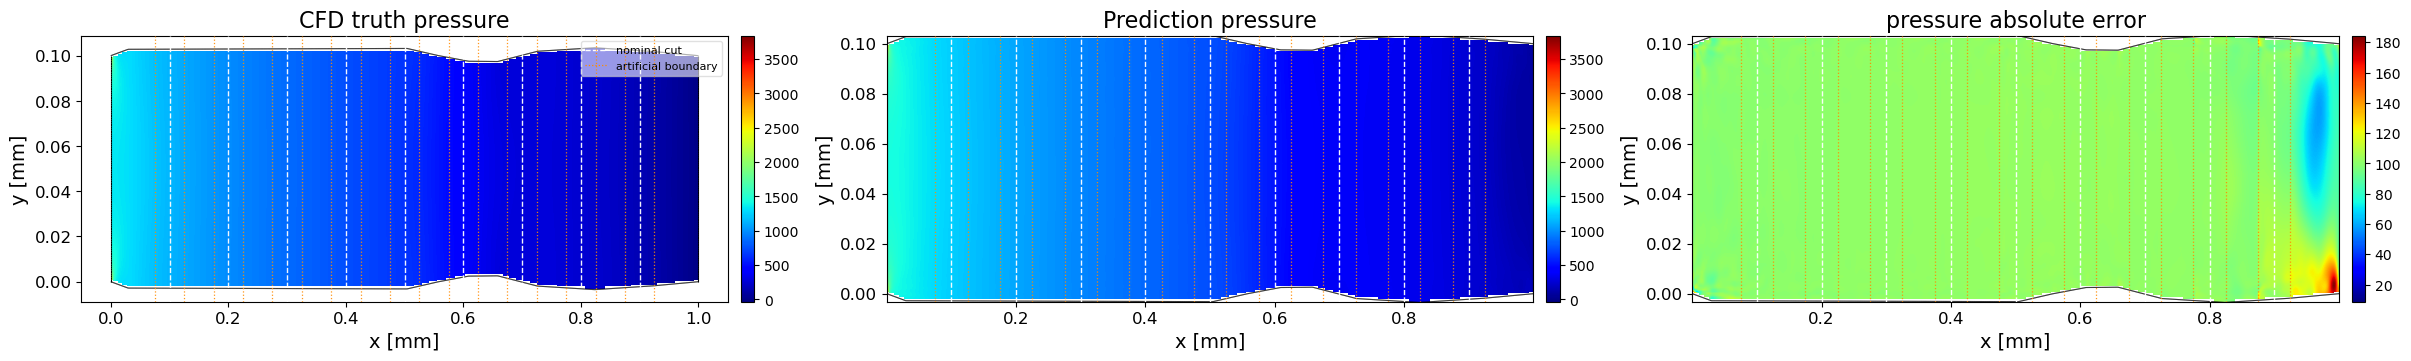

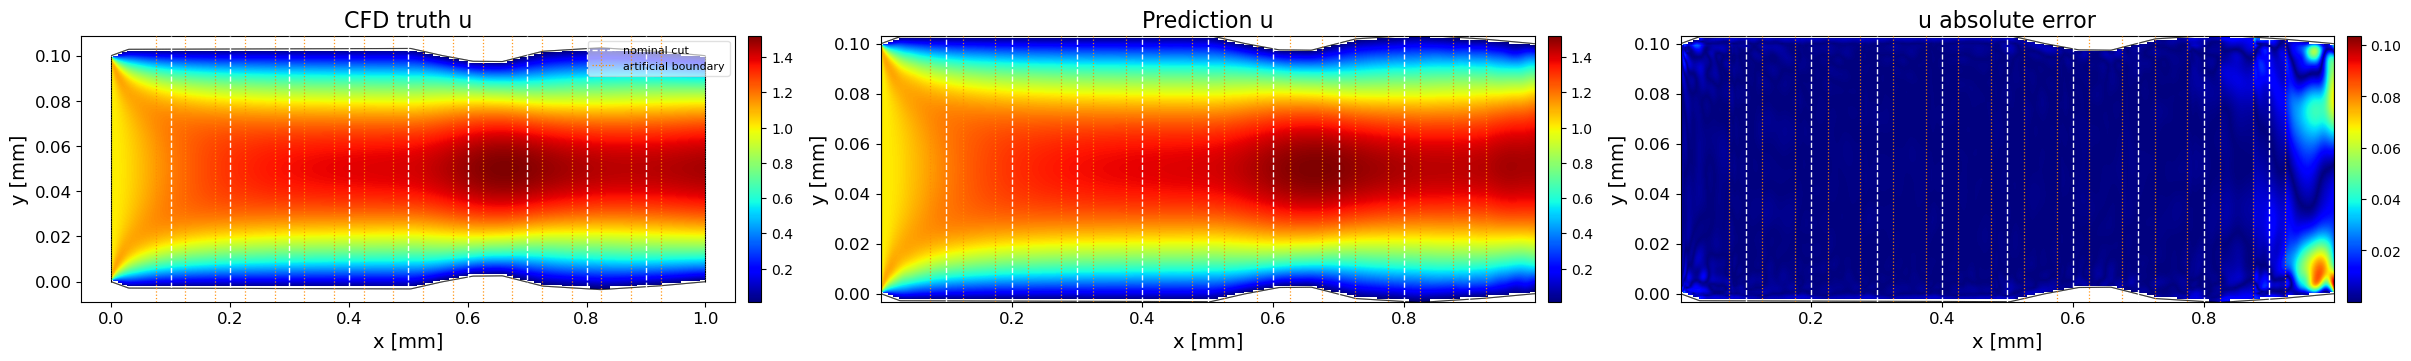

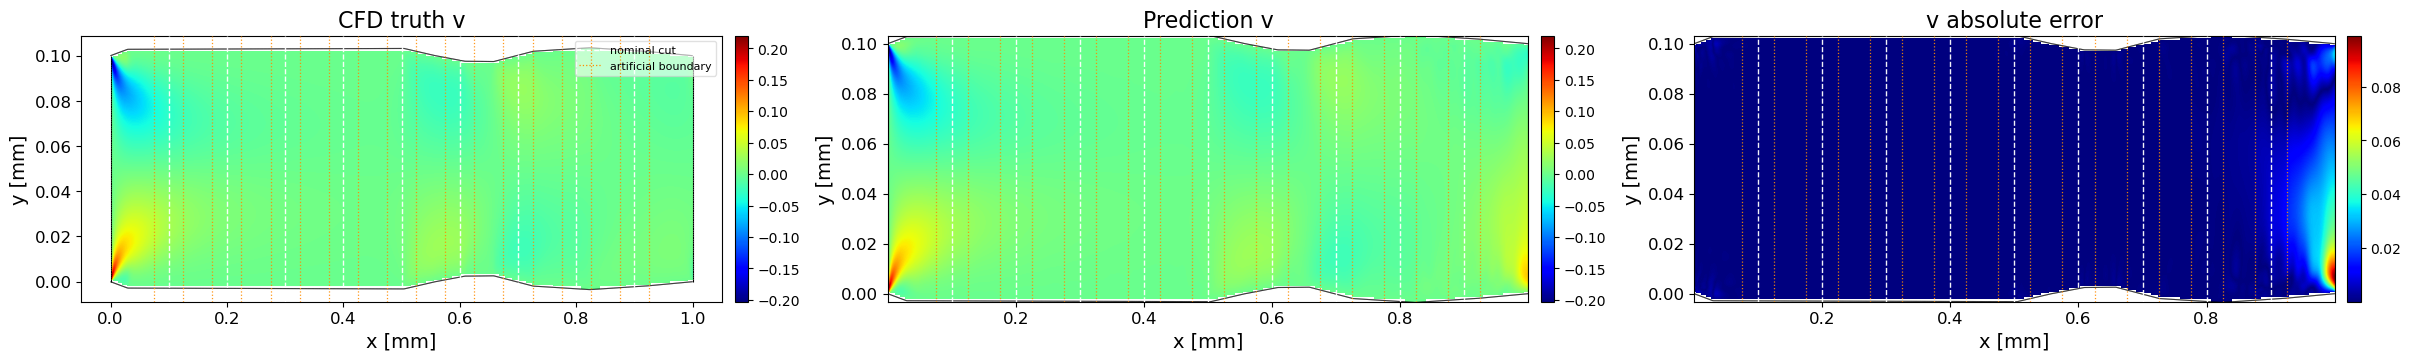

In [13]:
# Uses `dec` and `result` from the single-case section above.
_ = plot_sni_case_all_fields(
    dec,
    result["solution"],
    field_names=FIELD_NAMES,
    mesh_h5=case_paths(CASE)["mesh"],   # masks pixels outside the channel walls
    figsize=(24, 3.5),
    n_y_plot=140,
    coord_unit="mm",
    # output_dir="figures", filename_prefix=f"sni_{CASE}",
)